# Mixed PINN for 2D linear elastostatics with scaling

The goal is to simultaneously approximate two displacement components and three components of the symmetric stress tensor on the domain

$$
\Omega=(0,1)^2.
$$

The network operates with scaled coordinates and outputs

$$
\widehat{\mathbf q}_\theta(\widehat x,\widehat y)
=
\begin{bmatrix}
\widehat u_{1,\theta} & \widehat u_{2,\theta} &
\widehat\sigma_{xx,\theta} & \widehat\sigma_{yy,\theta} &
\widehat\sigma_{xy,\theta}
\end{bmatrix}^{\mathsf T}.
$$

The exact displacement is

$$
\mathbf u_{\mathrm{exact}}(x,y)
=a
\begin{bmatrix}
\cos x-y^2\\
2\sin x+y
\end{bmatrix},
\qquad a=0.005.
$$

The material parameters are

$$
E=10^{10},
\qquad \nu=\frac14,
\qquad \lambda=\mu=\frac{2E}{5}=4\cdot10^9.
$$

## Reference quantities

We use the scaling

$$
\mathbf x=L_{\mathrm{ref}}\widehat{\mathbf x},
\qquad
\mathbf u=U_{\mathrm{ref}}\widehat{\mathbf u},
$$

where

$$
L_{\mathrm{ref}}=\operatorname{diam}(\Omega)=\sqrt2
$$

a

$$
U_{\mathrm{ref}}
=\max_{\Gamma_D}\|\mathbf u_{\mathrm{exact}}\|_2
=a\sqrt{(\cos1-1)^2+(2\sin1+1)^2}.
$$

The maximum on the Dirichlet part of the boundary occurs at the point $(1,1)$. We further define

$$
\varepsilon_{\mathrm{ref}}=\frac{U_{\mathrm{ref}}}{L_{\mathrm{ref}}},
\qquad
\sigma_{\mathrm{ref}}=E\frac{U_{\mathrm{ref}}}{L_{\mathrm{ref}}},
$$

$$
b_{\mathrm{ref}}=E\frac{U_{\mathrm{ref}}}{L_{\mathrm{ref}}^2},
\qquad
t_{\mathrm{ref}}=\sigma_{\mathrm{ref}}.
$$

The scaled domain is

$$
\widehat\Omega=\left(0,\frac1{\sqrt2}\right)^2.
$$

## Scaled strong form

For

$$
\widehat{\boldsymbol\varepsilon}
=\frac12\left(
\nabla_{\widehat{\mathbf x}}\widehat{\mathbf u}
+\nabla_{\widehat{\mathbf x}}\widehat{\mathbf u}^{\mathsf T}
\right)
$$

we have

$$
\widehat{\boldsymbol\sigma}
=\frac{\lambda}{E}
\operatorname{tr}(\widehat{\boldsymbol\varepsilon})\mathbf I
+2\frac{\mu}{E}\widehat{\boldsymbol\varepsilon},
$$

$$
\nabla_{\widehat{\mathbf x}}\cdot\widehat{\boldsymbol\sigma}
+\widehat{\mathbf b}=\mathbf0,
\qquad
\widehat{\mathbf b}=\frac{\mathbf b}{b_{\mathrm{ref}}}.
$$

Since $\lambda/E=\mu/E=2/5$, the magnitude of Young's modulus does not appear in the scaled residuals. On $\Gamma_D$, we use $\widehat{\mathbf u}_D=\mathbf u_D/U_{\mathrm{ref}}$, and on $\Gamma_N$, the scaled traction $\widehat{\mathbf t}=\mathbf t/t_{\mathrm{ref}}$.

## 1. Library imports


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset


/home/eliska/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## 2. Parameters and reference quantities

- `USE_DATA = False`: pure mixed PINN.
- `USE_DATA = True`: adds a loss term for known scaled values of all five fields.
- The first 1900 epochs use Adam and the final 100 epochs use L-BFGS.
- The network takes $(\widehat x,\widehat y)$ as input and returns $(\widehat{\mathbf u},\widehat{\boldsymbol\sigma})$.

In [2]:
USE_DATA = True

E = 1.0e10
NU = 1.0 / 4.0
AMPLITUDE = 0.005

# Lame constants.
LAMBDA = E * NU / ((1.0 + NU) * (1.0 - 2.0 * NU))
MU = E / (2.0 * (1.0 + NU))

# Chosen reference quantities.
L_REF = np.sqrt(2.0)
U_REF = AMPLITUDE * np.sqrt((np.cos(1.0) - 1.0) ** 2 + (2.0 * np.sin(1.0) + 1.0) ** 2)
EPS_REF = U_REF / L_REF
STRESS_REF = E * U_REF / L_REF
BODY_FORCE_REF = STRESS_REF / L_REF
TRACTION_REF = STRESS_REF

# Dimensionless material constants and the size of the scaled domain.
LAMBDA_SCALED = LAMBDA / E
MU_SCALED = MU / E
DOMAIN_MAX_SCALED = 1.0 / L_REF

N_PDE_TRAIN = 2000
N_PDE_TEST = 2000
PDE_BATCH_SIZE = 64
N_BOUNDARY_PER_EDGE = 100
N_DATA_TRAIN = 200
N_DATA_TEST = 200

EPOCHS = 2000
LBFGS_EPOCHS = 100
LR = 1e-3
SEED = 42

torch.manual_seed(SEED)

E_FROM_LAME = MU * (3.0 * LAMBDA + 2.0 * MU) / (LAMBDA + MU)
NU_FROM_LAME = LAMBDA / (2.0 * (LAMBDA + MU))

## 3. Exact and scaled quantities

Functions with the `_real` suffix return values in the original units. Functions with the `_scaled` suffix take scaled coordinates and return the scaled quantities used in the loss.

In [3]:
def to_real_coordinates(xy_scaled):
    'Transformation x = L_ref * x_hat.'
    return L_REF * xy_scaled


def exact_displacement_real(xy_real):
    'Exact displacement [u1, u2].'
    x = xy_real[:, 0:1]
    y = xy_real[:, 1:2]

    u1 = AMPLITUDE * (torch.cos(x) - y**2)
    u2 = AMPLITUDE * (2.0 * torch.sin(x) + y)
    return torch.cat((u1, u2), dim=1)


def exact_stress_real(xy_real):
    'Exact stress components [sigma_xx, sigma_yy, sigma_xy].'
    x = xy_real[:, 0:1]
    y = xy_real[:, 1:2]
    a = AMPLITUDE

    eps_xx = -a * torch.sin(x)
    eps_yy = a * torch.ones_like(x)
    eps_xy = a * (torch.cos(x) - y)
    trace_eps = eps_xx + eps_yy

    sigma_xx = LAMBDA * trace_eps + 2.0 * MU * eps_xx
    sigma_yy = LAMBDA * trace_eps + 2.0 * MU * eps_yy
    sigma_xy = 2.0 * MU * eps_xy
    return torch.cat((sigma_xx, sigma_yy, sigma_xy), dim=1)


def body_force_real(xy_real):
    'Exact body force b = -div(sigma_exact).'
    x = xy_real[:, 0:1]
    a = AMPLITUDE

    b1 = a * (LAMBDA + 2.0 * MU) * torch.cos(x) + 2.0 * MU * a
    b2 = 2.0 * MU * a * torch.sin(x)
    return torch.cat((b1, b2), dim=1)


def exact_displacement_scaled(xy_scaled):
    xy_real = to_real_coordinates(xy_scaled)
    return exact_displacement_real(xy_real) / U_REF


def exact_stress_scaled(xy_scaled):
    xy_real = to_real_coordinates(xy_scaled)
    return exact_stress_real(xy_real) / STRESS_REF


def exact_fields_scaled(xy_scaled):
    return torch.cat((exact_displacement_scaled(xy_scaled), exact_stress_scaled(xy_scaled)), dim=1,)


def body_force_scaled(xy_scaled):
    xy_real = to_real_coordinates(xy_scaled)
    return body_force_real(xy_real) / BODY_FORCE_REF


def exact_traction_scaled(xy_scaled, normals):
    stress_scaled = exact_stress_scaled(xy_scaled)
    sigma_xx = stress_scaled[:, 0:1]
    sigma_yy = stress_scaled[:, 1:2]
    sigma_xy = stress_scaled[:, 2:3]

    nx = normals[:, 0:1]
    ny = normals[:, 1:2]

    traction_x = sigma_xx * nx + sigma_xy * ny
    traction_y = sigma_xy * nx + sigma_yy * ny
    return torch.cat((traction_x, traction_y), dim=1)


def scaled_fields_to_real(fields_scaled):
    'Convert the five scaled fields back to the original units.'
    displacement = U_REF * fields_scaled[:, 0:2]
    stress = STRESS_REF * fields_scaled[:, 2:5]
    return torch.cat((displacement, stress), dim=1)

## 4. Neural network with five scaled outputs

The network outputs are ordered as

$$
[\widehat u_{1,\theta},\widehat u_{2,\theta},
\widehat\sigma_{xx,\theta},\widehat\sigma_{yy,\theta},
\widehat\sigma_{xy,\theta}].
$$

In [4]:
class MixedPINN(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(2, 20),
            nn.Tanh(),
            nn.Linear(20, 20),
            nn.Tanh(),
            nn.Linear(20, 20),
            nn.Tanh(),
            nn.Linear(20, 20),
            nn.Tanh(),
            nn.Linear(20, 20),
            nn.Tanh(),
            nn.Linear(20, 5),
        )

    def forward(self, xy):
        return self.net(xy)


model = MixedPINN()
optimizer_adam = torch.optim.Adam(model.parameters(), lr=LR)


## 5. Training, test, and boundary points

All points stored in the `xy_*` variables are scaled. Therefore, the physical boundary $x=1$ or $y=1$ corresponds to the value $1/L_{\mathrm{ref}}$.

- `xy_pde_train`: scaled collocation points; they are batched with a `DataLoader` during Adam training.
- `pde_loader`: batches containing only interior points; `shuffle=True` reshuffles them in every epoch.
- `xy_pde_test`: independent scaled test points.
- `xy_dirichlet`: points on the boundaries $\widehat x=0$ and $\widehat x=1/L_{\mathrm{ref}}$.
- `xy_neumann`: points on the boundaries $\widehat y=0$ and $\widehat y=1/L_{\mathrm{ref}}$.

In [5]:
pde_train_generator = torch.Generator().manual_seed(SEED + 1)
xy_pde_train = DOMAIN_MAX_SCALED * torch.rand(N_PDE_TRAIN, 2, generator=pde_train_generator,)

pde_dataset = TensorDataset(xy_pde_train)
pde_batch_generator = torch.Generator().manual_seed(SEED + 5)
pde_loader = DataLoader(pde_dataset, batch_size=PDE_BATCH_SIZE, shuffle=True, generator=pde_batch_generator,)

pde_test_generator = torch.Generator().manual_seed(SEED + 2)
xy_pde_test = DOMAIN_MAX_SCALED * torch.rand(N_PDE_TEST, 2, generator=pde_test_generator,)
xy_pde_test.requires_grad_(True)

t_scaled = torch.linspace(0.0, DOMAIN_MAX_SCALED, N_BOUNDARY_PER_EDGE).view(-1, 1)

# Dirichlet points at x_hat=0 and x_hat=1/L_ref.
left = torch.cat((torch.zeros_like(t_scaled), t_scaled), dim=1)
right = torch.cat((DOMAIN_MAX_SCALED * torch.ones_like(t_scaled), t_scaled), dim=1)
xy_dirichlet = torch.cat((left, right), dim=0)
u_dirichlet_scaled = exact_displacement_scaled(xy_dirichlet)

# Neumann points at y_hat=0 and y_hat=1/L_ref.
bottom = torch.cat((t_scaled, torch.zeros_like(t_scaled)), dim=1)
top = torch.cat((t_scaled, DOMAIN_MAX_SCALED * torch.ones_like(t_scaled)), dim=1)

normal_bottom = torch.cat((torch.zeros_like(t_scaled), -torch.ones_like(t_scaled)),dim=1,)
normal_top = torch.cat((torch.zeros_like(t_scaled), torch.ones_like(t_scaled)), dim=1,)

xy_neumann = torch.cat((bottom, top), dim=0)
normals_neumann = torch.cat((normal_bottom, normal_top), dim=0)
traction_neumann_scaled = exact_traction_scaled(xy_neumann, normals_neumann)

if USE_DATA:
    data_train_generator = torch.Generator().manual_seed(SEED + 3)
    xy_data_train = DOMAIN_MAX_SCALED * torch.rand(N_DATA_TRAIN, 2, generator=data_train_generator,)
    fields_data_train_scaled = exact_fields_scaled(xy_data_train)

    data_test_generator = torch.Generator().manual_seed(SEED + 4)
    xy_data_test = DOMAIN_MAX_SCALED * torch.rand(N_DATA_TEST,2, generator=data_test_generator,)
    fields_data_test_scaled = exact_fields_scaled(xy_data_test)

## 6. Scaled equilibrium and constitutive residuals

Because the network predicts the scaled stress independently, the physics loss contains two parts. The equilibrium residual is

$$
\widehat{\mathbf r}_{\mathrm{eq},\theta}
=\nabla_{\widehat{\mathbf x}}\cdot
\widehat{\boldsymbol\sigma}_\theta+\widehat{\mathbf b}.
$$

The constitutive residual is

$$
\widehat{\mathbf r}_{\mathrm{const},\theta}
=\widehat{\boldsymbol\sigma}_\theta-
\left[
\frac{\lambda}{E}
\operatorname{tr}(\widehat{\boldsymbol\varepsilon})\mathbf I
+2\frac{\mu}{E}\widehat{\boldsymbol\varepsilon}
\right].
$$

The total scaled loss is

$$
\mathcal L=\mathcal L_{\mathrm{eq}}
+\mathcal L_{\mathrm{const}}
+\mathcal L_{\mathrm D}
+\mathcal L_{\mathrm N}
+\mathcal L_{\mathrm{data}}.
$$

All terms compare quantities of order one. For `USE_DATA = False`, $\mathcal L_{\mathrm{data}}=0$.

In [ ]:
def split_prediction(prediction_scaled):
    u1_scaled = prediction_scaled[:, 0:1]
    u2_scaled = prediction_scaled[:, 1:2]
    sigma_xx_scaled = prediction_scaled[:, 2:3]
    sigma_yy_scaled = prediction_scaled[:, 3:4]
    sigma_xy_scaled = prediction_scaled[:, 4:5]
    return (u1_scaled, u2_scaled, sigma_xx_scaled, sigma_yy_scaled, sigma_xy_scaled,)


def constitutive_stress_from_displacement_scaled(xy_scaled, u1_scaled, u2_scaled, create_graph,):
    'Returns sigma_hat from the gradient of u_hat with respect to x_hat.'
    grad_u1_scaled = torch.autograd.grad(u1_scaled, xy_scaled, grad_outputs=torch.ones_like(u1_scaled), create_graph=create_graph, retain_graph=True,)[0]
    grad_u2_scaled = torch.autograd.grad(u2_scaled, xy_scaled, grad_outputs=torch.ones_like(u2_scaled), create_graph=create_graph, retain_graph=True,)[0]

    eps_xx_scaled = grad_u1_scaled[:, 0:1]
    eps_yy_scaled = grad_u2_scaled[:, 1:2]
    eps_xy_scaled = 0.5 * (grad_u1_scaled[:, 1:2] + grad_u2_scaled[:, 0:1])
    trace_eps_scaled = eps_xx_scaled + eps_yy_scaled

    sigma_xx_scaled = (LAMBDA_SCALED * trace_eps_scaled + 2.0 * MU_SCALED * eps_xx_scaled)
    sigma_yy_scaled = (LAMBDA_SCALED * trace_eps_scaled + 2.0 * MU_SCALED * eps_yy_scaled)
    sigma_xy_scaled = 2.0 * MU_SCALED * eps_xy_scaled
    return torch.cat((sigma_xx_scaled, sigma_yy_scaled, sigma_xy_scaled), dim=1)


def mixed_residuals(xy_scaled, training=True):
    prediction_scaled = model(xy_scaled)
    values = split_prediction(prediction_scaled)
    u1_scaled, u2_scaled = values[0], values[1]
    sigma_xx_scaled, sigma_yy_scaled, sigma_xy_scaled = values[2:]

    constitutive_stress_scaled = (constitutive_stress_from_displacement_scaled(xy_scaled, u1_scaled, u2_scaled, create_graph=training))
    predicted_stress_scaled = torch.cat((sigma_xx_scaled, sigma_yy_scaled, sigma_xy_scaled), dim=1)
    residual_constitutive_scaled = (predicted_stress_scaled - constitutive_stress_scaled)

    grad_sigma_xx_scaled = torch.autograd.grad(sigma_xx_scaled, xy_scaled, grad_outputs=torch.ones_like(sigma_xx_scaled), create_graph=training, retain_graph=True)[0]
    grad_sigma_yy_scaled = torch.autograd.grad(sigma_yy_scaled, xy_scaled, grad_outputs=torch.ones_like(sigma_yy_scaled), create_graph=training, retain_graph=True)[0]
    grad_sigma_xy_scaled = torch.autograd.grad(sigma_xy_scaled, xy_scaled, grad_outputs=torch.ones_like(sigma_xy_scaled), create_graph=training, retain_graph=True)[0]

    b_scaled = body_force_scaled(xy_scaled)
    residual_1_scaled = (grad_sigma_xx_scaled[:, 0:1] + grad_sigma_xy_scaled[:, 1:2] + b_scaled[:, 0:1])
    residual_2_scaled = (grad_sigma_xy_scaled[:, 0:1] + grad_sigma_yy_scaled[:, 1:2] + b_scaled[:, 1:2])
    residual_equilibrium_scaled = torch.cat((residual_1_scaled, residual_2_scaled), dim=1)

    return (residual_equilibrium_scaled, residual_constitutive_scaled, prediction_scaled)


def compute_losses(xy_pde):
    xy_pde = xy_pde.requires_grad_(True)
    residual_eq, residual_const, _ = mixed_residuals(xy_pde, training=True,)
    loss_equilibrium = torch.mean(residual_eq**2)
    loss_constitutive = torch.mean(residual_const**2)

    dirichlet_prediction_scaled = model(xy_dirichlet)[:, 0:2]
    loss_dirichlet = torch.mean((dirichlet_prediction_scaled - u_dirichlet_scaled) ** 2)

    neumann_prediction_scaled = model(xy_neumann)
    values = split_prediction(neumann_prediction_scaled)
    sigma_xx_scaled, sigma_yy_scaled, sigma_xy_scaled = values[2:]
    nx = normals_neumann[:, 0:1]
    ny = normals_neumann[:, 1:2]
    traction_x_scaled = sigma_xx_scaled * nx + sigma_xy_scaled * ny
    traction_y_scaled = sigma_xy_scaled * nx + sigma_yy_scaled * ny
    traction_prediction_scaled = torch.cat((traction_x_scaled, traction_y_scaled), dim=1)
    loss_neumann = torch.mean((traction_prediction_scaled - traction_neumann_scaled) ** 2)
    loss_boundary = loss_dirichlet + loss_neumann

    if USE_DATA:
        data_prediction_scaled = model(xy_data_train)
        loss_data = torch.mean((data_prediction_scaled - fields_data_train_scaled) ** 2)
    else:
        loss_data = torch.tensor(0.0)

    loss = (loss_equilibrium + loss_constitutive + loss_boundary + loss_data)

    return (loss, loss_equilibrium, loss_constitutive, loss_boundary, loss_data) 

## 7. Training: Adam and L-BFGS

The first 1900 epochs use Adam. In each epoch, shuffled mini-batches contain only interior PDE points. The complete sets of Dirichlet, Neumann, and optional data points are used in every Adam step. The final 100 epochs use L-BFGS with a `closure` function and all interior points at once.


In [7]:
loss_history = []
equilibrium_loss_history = []
constitutive_loss_history = []
boundary_loss_history = []
data_loss_history = []

ADAM_EPOCHS = EPOCHS - LBFGS_EPOCHS

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_adam,
    mode="min",
    factor=0.5,
    patience=200,
)

for epoch in range(ADAM_EPOCHS):
    epoch_sums = np.zeros(5)

    # DataLoader creates a new random ordering of the PDE points in each epoch.
    for (xy_pde_batch,) in pde_loader:
        optimizer_adam.zero_grad()

        losses = compute_losses(xy_pde_batch)
        loss, loss_eq, loss_const, loss_bc, loss_data = losses
        loss.backward()
        optimizer_adam.step()

        epoch_sums += np.array([value.detach().item() for value in losses])

    epoch_losses = epoch_sums / len(pde_loader)
    loss_value, eq_value, const_value, bc_value, data_value = (epoch_losses)
    scheduler.step(loss_value)

    loss_history.append(loss_value)
    equilibrium_loss_history.append(eq_value)
    constitutive_loss_history.append(const_value)
    boundary_loss_history.append(bc_value)
    data_loss_history.append(data_value)

    if epoch % 500 == 0:
        print(
            f"Adam | epoch {epoch:5d} | loss={loss_value:.6e} | "
            f"eq={eq_value:.6e} | const={const_value:.6e} | "
            f"BC={bc_value:.6e} | data={data_value:.6e}"
        )

print(f"Switching from Adam to L-BFGS at epoch {ADAM_EPOCHS}.")

optimizer_lbfgs = torch.optim.LBFGS(model.parameters(), lr=1.0, max_iter=20, history_size=50, line_search_fn="strong_wolfe")

for lbfgs_epoch in range(LBFGS_EPOCHS):
    epoch = ADAM_EPOCHS + lbfgs_epoch

    def closure():
        optimizer_lbfgs.zero_grad()
        loss, _, _, _, _ = compute_losses(xy_pde_train)
        loss.backward()
        return loss

    optimizer_lbfgs.step(closure)

    losses = compute_losses(xy_pde_train)
    loss, loss_eq, loss_const, loss_bc, loss_data = losses

    loss_history.append(loss.detach().item())
    equilibrium_loss_history.append(loss_eq.detach().item())
    constitutive_loss_history.append(loss_const.detach().item())
    boundary_loss_history.append(loss_bc.detach().item())
    data_loss_history.append(loss_data.detach().item())

    if lbfgs_epoch % 50 == 0 or lbfgs_epoch == LBFGS_EPOCHS - 1:
        print(
            f"L-BFGS | epoch {epoch:5d} | loss={loss.item():.6e} | "
            f"eq={loss_eq.item():.6e} | const={loss_const.item():.6e} | "
            f"BC={loss_bc.item():.6e} | data={loss_data.item():.6e}"
        )

model.eval()


Adam | epoch     0 | loss=1.058532e+00 | eq=6.874718e-01 | const=4.580585e-02 | BC=2.391755e-01 | data=8.607887e-02
Adam | epoch   500 | loss=2.251497e-05 | eq=1.898886e-06 | const=1.738038e-05 | BC=2.051388e-06 | data=1.184318e-06
Adam | epoch  1000 | loss=2.752373e-06 | eq=6.209759e-07 | const=1.235989e-06 | BC=5.984098e-07 | data=2.969988e-07
Adam | epoch  1500 | loss=3.878625e-07 | eq=1.039663e-07 | const=1.995603e-07 | BC=4.911996e-08 | data=3.521594e-08
Switching from Adam to L-BFGS at epoch 1900.
L-BFGS | epoch  1900 | loss=2.645654e-07 | eq=7.641791e-08 | const=1.325430e-07 | BC=3.381228e-08 | data=2.179221e-08
L-BFGS | epoch  1950 | loss=2.645654e-07 | eq=7.641791e-08 | const=1.325430e-07 | BC=3.381228e-08 | data=2.179221e-08
L-BFGS | epoch  1999 | loss=2.645654e-07 | eq=7.641791e-08 | const=1.325430e-07 | BC=3.381228e-08 | data=2.179221e-08


MixedPINN(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=20, bias=True)
    (1): Tanh()
    (2): Linear(in_features=20, out_features=20, bias=True)
    (3): Tanh()
    (4): Linear(in_features=20, out_features=20, bias=True)
    (5): Tanh()
    (6): Linear(in_features=20, out_features=20, bias=True)
    (7): Tanh()
    (8): Linear(in_features=20, out_features=20, bias=True)
    (9): Tanh()
    (10): Linear(in_features=20, out_features=5, bias=True)
  )
)

## 8. Testing on independent points

The predicted scaled quantities are first converted back to the original units. We evaluate:

- the $R^2$ score and relative $L^2$ error of the displacement in the original units,
- the $R^2$ score and relative $L^2$ error of the stress in the original units.

In [8]:
model.eval()
xy_pde_test.grad = None

residual_eq_test, residual_const_test, prediction_test_scaled = mixed_residuals(xy_pde_test, training=False)

prediction_test_scaled = prediction_test_scaled.detach()
exact_test_scaled = exact_fields_scaled(xy_pde_test).detach()

prediction_test_real = scaled_fields_to_real(prediction_test_scaled)
exact_test_real = scaled_fields_to_real(exact_test_scaled)

u_prediction = prediction_test_real[:, 0:2]
u_exact = exact_test_real[:, 0:2]
stress_prediction = prediction_test_real[:, 2:5]
stress_exact = exact_test_real[:, 2:5]


def r2_score(prediction, exact):
    ss_res = torch.sum((prediction - exact) ** 2)
    ss_tot = torch.sum((exact - torch.mean(exact)) ** 2)
    return (1.0 - ss_res / ss_tot).item()


def relative_l2(prediction, exact):
    return (torch.linalg.vector_norm(prediction - exact) / torch.linalg.vector_norm(exact)).item()


r2_u = r2_score(u_prediction, u_exact)
relative_l2_u = relative_l2(u_prediction, u_exact)
r2_stress = r2_score(stress_prediction, stress_exact)
relative_l2_stress = relative_l2(stress_prediction, stress_exact)

metrics = {
    "R2_displacement_real": r2_u,
    "relative_L2_displacement_real": relative_l2_u,
    "R2_stress_real": r2_stress,
    "relative_L2_stress_real": relative_l2_stress,
}

print("=" * 72)
print("TEST RESULTS OF THE SCALED MIXED 2D PINN")
print("=" * 72)
print(f"R2 displacement:                       {r2_u:.8f}")
print(f"Relative L2 displacement error:        {relative_l2_u:.6e}")
print(f"R2 stress:                             {r2_stress:.8f}")
print(f"Relative L2 stress error:              {relative_l2_stress:.6e}")
print("=" * 72)

metrics

TEST RESULTS OF THE SCALED MIXED 2D PINN
R2 displacement:                       0.99999994
Relative L2 displacement error:        1.106974e-04
R2 stress:                             0.99999952
Relative L2 stress error:              5.728999e-04


{'R2_displacement_real': 0.9999999403953552,
 'relative_L2_displacement_real': 0.0001106974232243374,
 'R2_stress_real': 0.9999995231628418,
 'relative_L2_stress_real': 0.0005728998803533614}

## 9. Visualization functions

For plotting, the coordinates and all five fields are converted back to the original units.

In [26]:
def make_grid(n=101, requires_grad=False):
    values_real = torch.linspace(0.0, 1.0, n)
    X, Y = torch.meshgrid(values_real, values_real, indexing="xy")
    xy_real = torch.stack((X.reshape(-1), Y.reshape(-1)), dim=1)
    xy_scaled = xy_real / L_REF

    if requires_grad:
        xy_scaled.requires_grad_(True)

    return X.numpy(), Y.numpy(), xy_scaled


def plot_points():
    fig, ax = plt.subplots(figsize=(7, 6))
    xy_pde_test_real = L_REF * xy_pde_test.detach()
    xy_pde_train_real = L_REF * xy_pde_train.detach()
    xy_dirichlet_real = L_REF * xy_dirichlet
    xy_neumann_real = L_REF * xy_neumann

    ax.scatter(
        xy_pde_test_real[:, 0].numpy(),
        xy_pde_test_real[:, 1].numpy(),
        s=8,
        alpha=0.25,
        label="PDE test",
    )
    ax.scatter(xy_pde_train_real[:, 0].numpy(), xy_pde_train_real[:, 1].numpy(), s=10, alpha=0.5, label="PDE train")
    ax.scatter(xy_dirichlet_real[:, 0].numpy(), xy_dirichlet_real[:, 1].numpy(), s=14, color="tab:red", label="Dirichlet")
    ax.scatter(xy_neumann_real[:, 0].numpy(), xy_neumann_real[:, 1].numpy(), s=14, color="black", label="Neumann")
    ax.set(title="Training, test, and boundary points", xlabel="x", ylabel="y",)
    ax.set_aspect("equal")
    ax.legend()
    ax.grid()
    fig.tight_layout()
    plt.show()


def plot_field_comparison(field_indices, names, filename, n=101):
    X, Y, xy_scaled = make_grid(n)

    with torch.no_grad():
        prediction_scaled = model(xy_scaled)
        exact_scaled = exact_fields_scaled(xy_scaled)
        prediction = scaled_fields_to_real(prediction_scaled).numpy().reshape(n, n, 5)
        exact = scaled_fields_to_real(exact_scaled).numpy().reshape(n, n, 5)

    error = np.abs(prediction - exact)
    nrows = len(field_indices)
    fig, axes = plt.subplots(nrows, 3, figsize=(15, 4.2 * nrows))

    if nrows == 1:
        axes = axes.reshape(1, 3)

    for row, (field_index, name) in enumerate(zip(field_indices, names)):
        limit = max( np.max(np.abs(exact[:, :, field_index])), np.max(np.abs(prediction[:, :, field_index])))

        images = [ axes[row, 0].contourf(X, Y, exact[:, :, field_index], levels=40, cmap="coolwarm", vmin=-limit, vmax=limit,),
                   axes[row, 1].contourf(X, Y, prediction[:, :, field_index], levels=40, cmap="coolwarm", vmin=-limit, vmax=limit,),
                   axes[row, 2].contourf(X, Y, error[:, :, field_index], levels=40, cmap="viridis",),]

        axes[row, 0].set_title(f"Exact {name}")
        axes[row, 1].set_title(f"PINN {name}")
        axes[row, 2].set_title(f"Absolute error {name}")

        for axis, image in zip(axes[row], images):
            axis.set(xlabel="x", ylabel="y")
            axis.set_aspect("equal")
            fig.colorbar(image, ax=axis)

    fig.tight_layout()
    plt.savefig(filename, bbox_inches="tight")
    plt.show()


def plot_displacement(n=101):
    plot_field_comparison(field_indices=[0, 1], names=["u1", "u2"], filename="mixed_pinn_scaled_displacement.pdf", n=n)


def plot_stress(n=101):
    plot_field_comparison(field_indices=[2, 3, 4], names=["sigma_xx", "sigma_yy", "sigma_xy"], filename="mixed_pinn_scaled_stress.pdf", n=n,)


def plot_deformed_domain(scale=1.0, n_lines=11, n_points=101):
    fig, ax = plt.subplots(figsize=(8, 8))
    coordinates = torch.linspace(0.0, 1.0, n_points)
    line_values = torch.linspace(0.0, 1.0, n_lines)
    first_line = True

    for value in line_values:
        horizontal_real = torch.stack((coordinates, value * torch.ones_like(coordinates)), dim=1)
        vertical_real = torch.stack((value * torch.ones_like(coordinates), coordinates), dim=1)

        for line_real in (horizontal_real, vertical_real):
            line_scaled = line_real / L_REF
            with torch.no_grad():
                exact_u_real = U_REF * exact_displacement_scaled(line_scaled)
                pinn_u_real = U_REF * model(line_scaled)[:, 0:2]
                exact_deformed = line_real + scale * exact_u_real
                pinn_deformed = line_real + scale * pinn_u_real

            ax.plot(line_real[:, 0].numpy(), line_real[:, 1].numpy(), color="gray", linestyle=":", alpha=0.4, label="original" if first_line else None,)
            ax.plot(exact_deformed[:, 0].numpy(), exact_deformed[:, 1].numpy(), "r--", alpha=0.8, label="exact deformation" if first_line else None,)
            ax.plot( pinn_deformed[:, 0].numpy(), pinn_deformed[:, 1].numpy(), color="tab:blue", alpha=0.8, label="PINN deformation" if first_line else None,)
            first_line = False

    ax.set( title=f"Deformed domain, displacement scale = {scale}", xlabel="x", ylabel="y",)
    ax.set_aspect("equal")
    ax.legend()
    ax.grid()
    fig.tight_layout()
    plt.savefig("mixed_pinn_scaled_deformed.pdf", bbox_inches="tight")
    plt.show()


def plot_residuals(n=101):
    X, Y, xy_scaled = make_grid(n, requires_grad=True)
    residual_eq, residual_const, _ = mixed_residuals(
        xy_scaled, training=False
    )
    residual_eq = residual_eq.detach().numpy().reshape(n, n, 2)
    residual_const = residual_const.detach().numpy().reshape(n, n, 3)

    names = [
        "r_eq_1_hat", "r_eq_2_hat",
        "r_const_xx_hat", "r_const_yy_hat", "r_const_xy_hat",
    ]
    values = [
        residual_eq[:, :, 0],
        residual_eq[:, :, 1],
        residual_const[:, :, 0],
        residual_const[:, :, 1],
        residual_const[:, :, 2],
    ]

    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    axes = axes.ravel()

    for axis, name, value in zip(axes, names, values):
        image = axis.contourf(X, Y, value, levels=40, cmap="coolwarm")
        axis.set(title=name, xlabel="x", ylabel="y")
        axis.set_aspect("equal")
        fig.colorbar(image, ax=axis)

    axes[-1].axis("off")
    fig.tight_layout()
    plt.savefig("mixed_pinn_scaled_residuals.pdf", bbox_inches="tight")
    plt.show()


def plot_loss():
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(loss_history, label="total")
    ax.plot(equilibrium_loss_history, label="equilibrium")
    ax.plot(constitutive_loss_history, label="constitutive")
    ax.plot(boundary_loss_history, label="boundary conditions")

    if USE_DATA:
        ax.plot(data_loss_history, label="data")

    ax.axvline(
        ADAM_EPOCHS,
        color="black",
        linestyle=":",
        label="switch to L-BFGS",
    )
    ax.set_yscale("log")
    ax.set(xlabel="epoch", ylabel="dimensionless loss")
    ax.legend()
    ax.grid()
    fig.tight_layout()
    plt.savefig("mixed_pinn_scaled_loss.pdf", bbox_inches="tight")
    plt.show()

## 10. Visualization


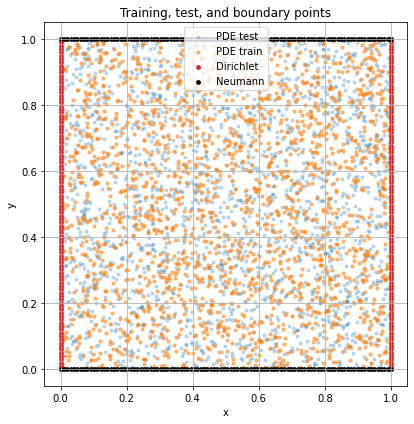

In [27]:
plot_points()


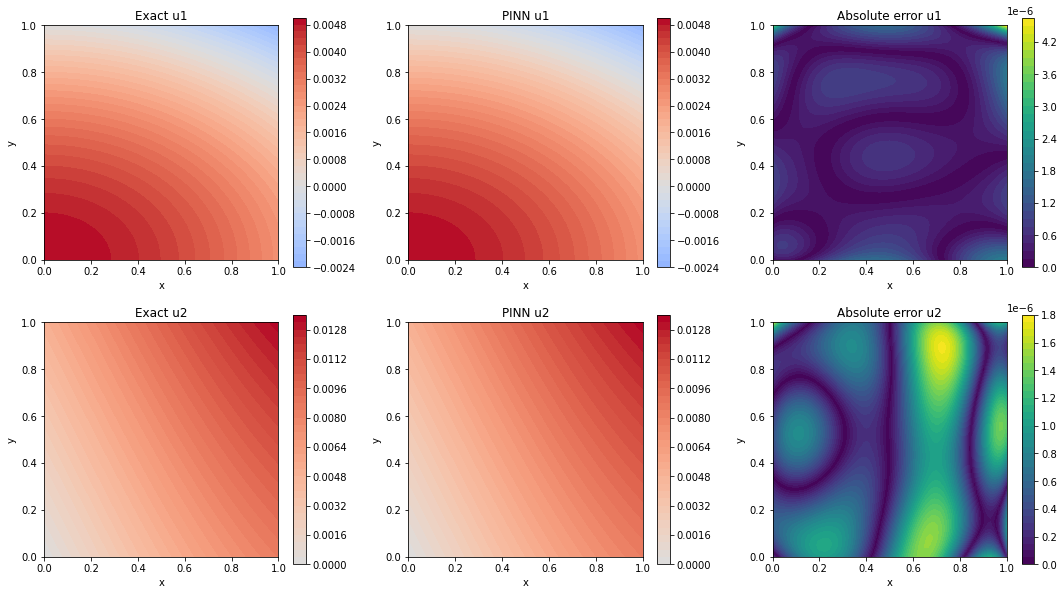

In [28]:
plot_displacement()


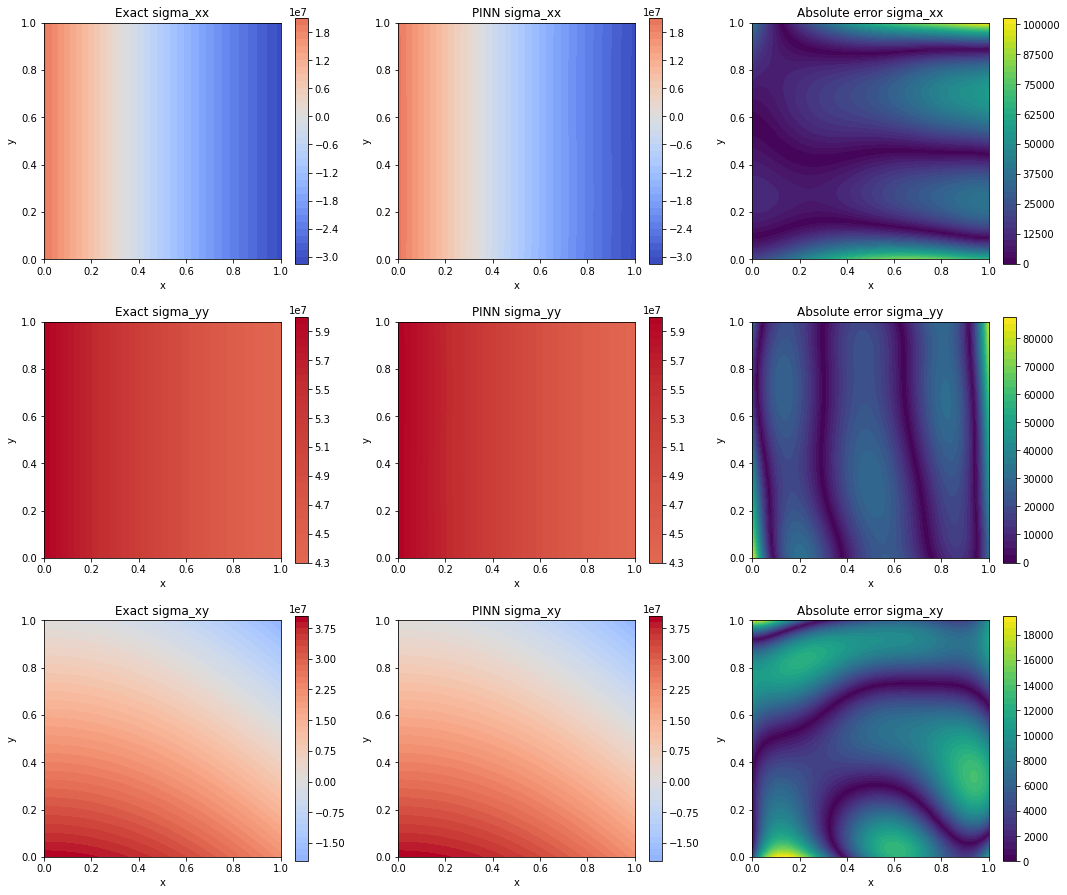

In [29]:
plot_stress()


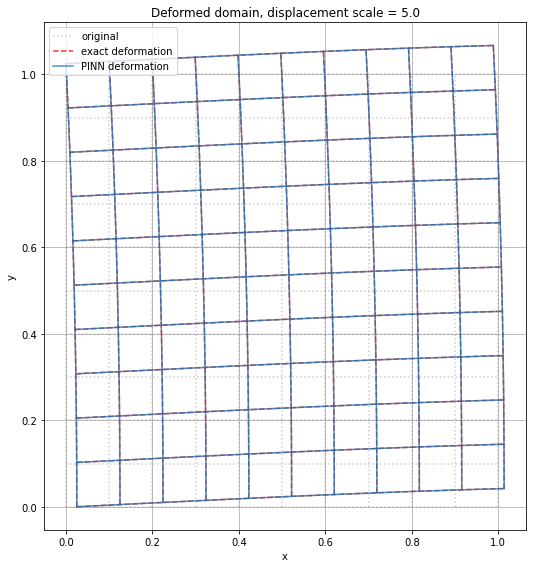

In [30]:
plot_deformed_domain(scale=5.0)


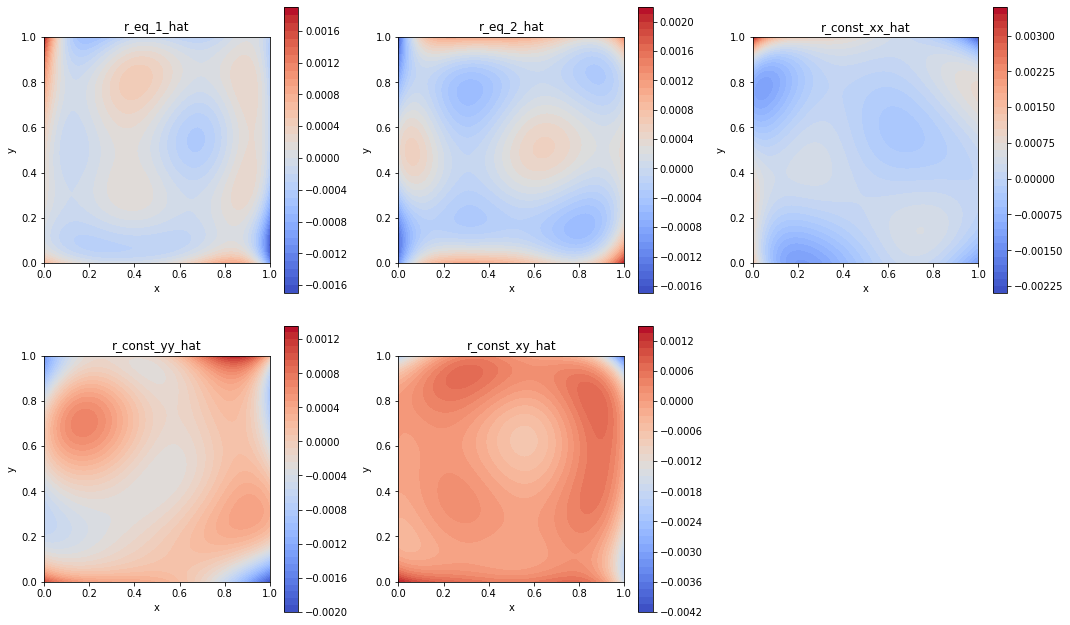

In [31]:
plot_residuals()


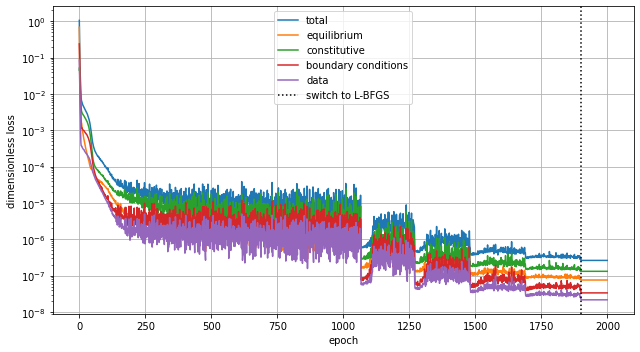

In [32]:
plot_loss()
